Question: What happens if we slowly decrease the learning rate?

In [1]:
import os, shutil
from training import TrainingHistory, fit_model
from training import fit_model
# from training_data import TrainingData, Normalizer
import matplotlib.pyplot as plt

2023-10-26 22:16:54.611731: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-26 22:16:55.524203: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
save_path = "models/test_rate_schedule"
training_data_path = "training_data"

In [3]:
from training_data import load_training_data
import keras.optimizers
training_data = load_training_data(training_data_path)
levels = list(training_data.levels.keys())
optimizers = {'Nadam': keras.optimizers.Nadam()}
save_paths = {opt:f"{save_path}/optimizer_{opt}" for opt in optimizers}

2023-10-26 22:16:59.685350: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22246 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


In [4]:
if os.path.exists(save_path):
    shutil.rmtree(save_path)
training_level = 'd0.40'
train_depth = 0.9
for optname, optimizer in optimizers.items():
    print(f"=== training with optimizer {optname} ===")
    fit_model(
        training_data=training_data_path,
        training_level=training_level,
        train_depth=train_depth,
        optimizer=optimizer,
        rate_scheduler={'delay': 2, 'decay': 0.8},
        save_path=save_paths[optname],
        model_type='ResNet101V2',
    )

=== training with optimizer Nadam ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10


2023-10-26 22:17:33.090067: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2023-10-26 22:17:34.481781: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-10-26 22:17:35.572719: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f97154e0c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-10-26 22:17:35.572742: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-10-26 22:17:35.584257: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-10-26 22:17:35.805515: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the p


Batch 0


2023-10-26 22:17:46.189475: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 9000000000 exceeds 10% of free system memory.
2023-10-26 22:17:52.245212: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 9000000000 exceeds 10% of free system memory.


saving weigts to models/test_rate_schedule/optimizer_Nadam/fit_weights
 100/1554 [>.............................] - ETA: 9:05 - loss: 0.0811
Batch 100


2023-10-26 22:19:03.802015: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 9000000000 exceeds 10% of free system memory.
2023-10-26 22:19:09.877763: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 9000000000 exceeds 10% of free system memory.


    Training MSE (xyz, xy, z): 0.10360170477095594 0.11662987201280658 0.07754537028725467  Slopes: [-0.013299393738620695, -0.013704053194890315, -0.011693436608210506]
    Validation d0.00  MSE (xyz, xy, z): 0.0667 0.0945 0.0111  Slopes: -0.0119 -0.0108 -0.0173
    Validation d0.20  MSE (xyz, xy, z): 0.0641 0.0848 0.0226  Slopes: -0.0139 -0.0137 -0.0155
    Validation d0.40  MSE (xyz, xy, z): 0.0985 0.124 0.0482  Slopes: -0.014 -0.0138 -0.0149
    Validation d0.60  MSE (xyz, xy, z): 0.228 0.266 0.151  Slopes: -0.0126 -0.0119 -0.0145
    Validation d0.80  MSE (xyz, xy, z): 0.59 0.692 0.386  Slopes: -0.00729 -0.00504 -0.0118
    Validation d1.00  MSE (xyz, xy, z): 0.955 1.2 0.467  Slopes: -0.00396 -0.00209 -0.00957
 200/1554 [==>...........................] - ETA: 12:44 - loss: 0.0602
Batch 200


2023-10-26 22:20:19.059219: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 9000000000 exceeds 10% of free system memory.


    Training MSE (xyz, xy, z): 0.04238396797669369 0.05470045824355092 0.017750987442979246  Slopes: [-0.010724350112877604, -0.010738935897537981, -0.010665011566820854]
    Validation d0.00  MSE (xyz, xy, z): 0.0144 0.0158 0.0117  Slopes: -0.0108 -0.0106 -0.012
    Validation d0.20  MSE (xyz, xy, z): 0.0202 0.0227 0.0153  Slopes: -0.0115 -0.0115 -0.0113
    Validation d0.40  MSE (xyz, xy, z): 0.0321 0.0374 0.0215  Slopes: -0.0114 -0.0114 -0.0116
    Validation d0.60  MSE (xyz, xy, z): 0.141 0.162 0.0986  Slopes: -0.00944 -0.00897 -0.0106
    Validation d0.80  MSE (xyz, xy, z): 0.643 0.783 0.361  Slopes: -0.00375 -0.00213 -0.00755
    Validation d1.00  MSE (xyz, xy, z): 0.987 1.26 0.444  Slopes: -0.00196 -0.000841 -0.00591
 300/1554 [====>.........................] - ETA: 13:08 - loss: 0.0511
Batch 300
    Training MSE (xyz, xy, z): 0.04039062779900223 0.05234715616554396 0.016477571065918763  Slopes: [-0.008468619370949768, -0.008386244853495749, -0.008811349090641405]
    Validation

INFO:tensorflow:Assets written to: models/test_rate_schedule/optimizer_Nadam/fit_model/assets


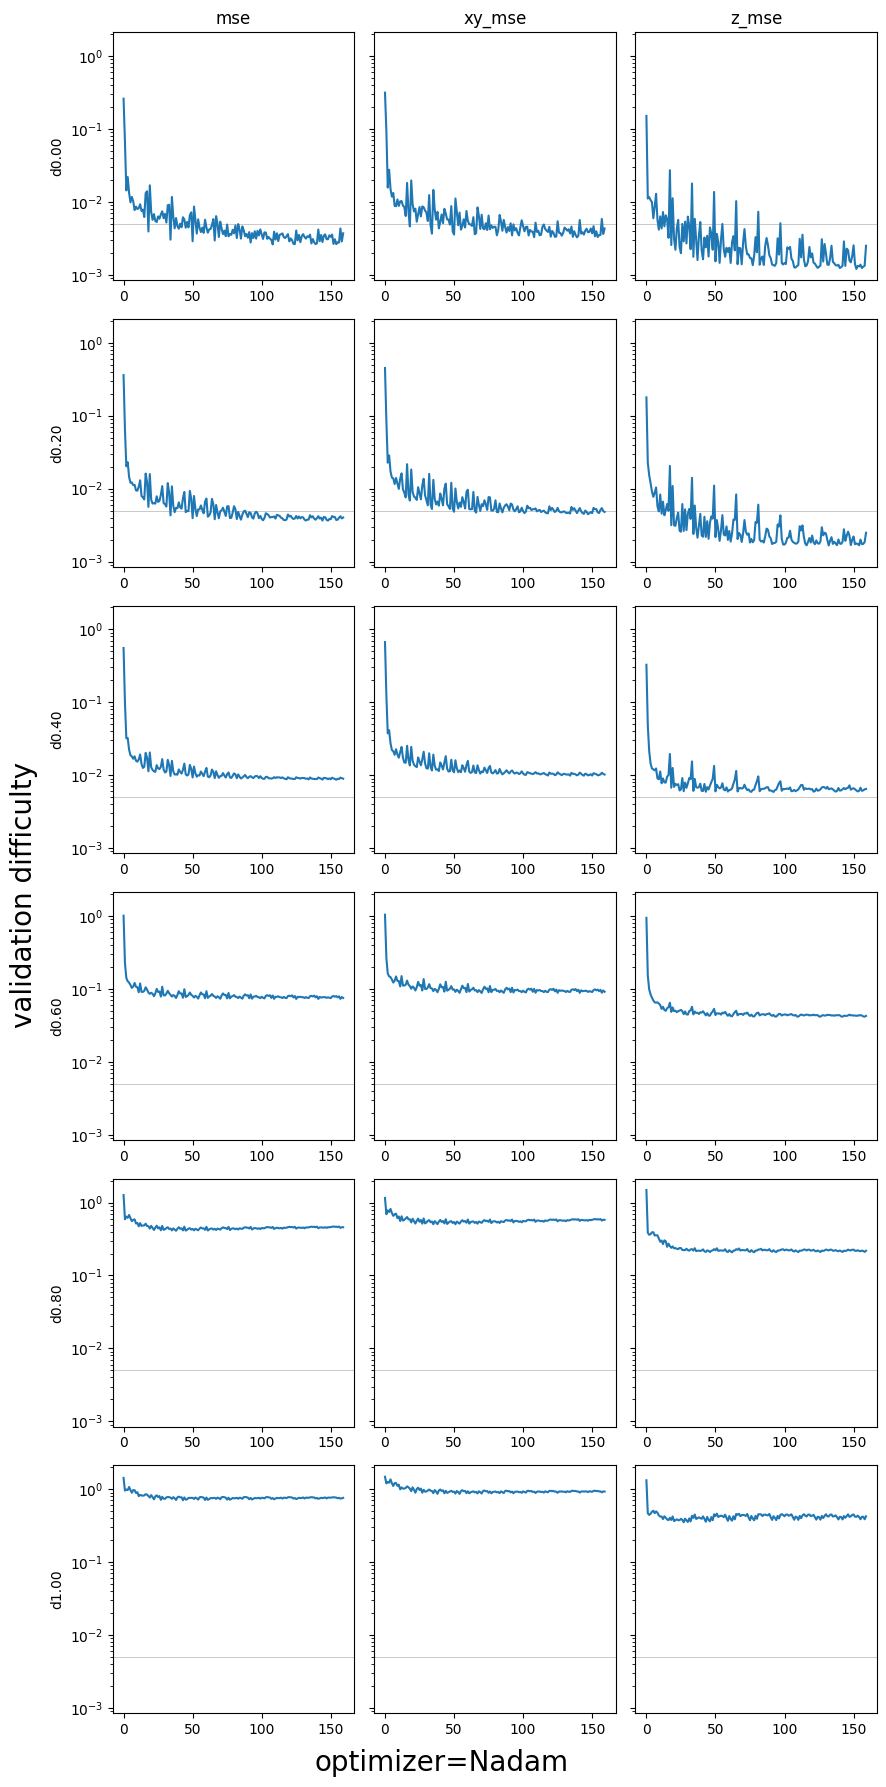

In [8]:
metrics = ['mse', 'xy_mse', 'z_mse']
fig, ax = plt.subplots(len(levels), len(metrics), figsize=(len(metrics)*3, len(levels)*3), sharey=True, squeeze=False)
fig.supylabel('validation difficulty', fontsize=20)
fig.supxlabel('optimizer=Nadam', fontsize=20)
for i, level in enumerate(levels):
    ax[i, 0].set_ylabel(level)
for i,metric in enumerate(metrics):
    history = TrainingHistory(f'{save_paths["Nadam"]}/training_history.json')
    history.plot_loss(metrics=[metric], ax=ax[:, i:i+1])
    ax[0, i].set_title(metric)
fig.tight_layout()

In [9]:
from model import PipetteDetectionModel
opt = 'Nadam'
model = PipetteDetectionModel(load_model=save_paths[opt])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None


1/1 [==============================] - 0s 66ms/step


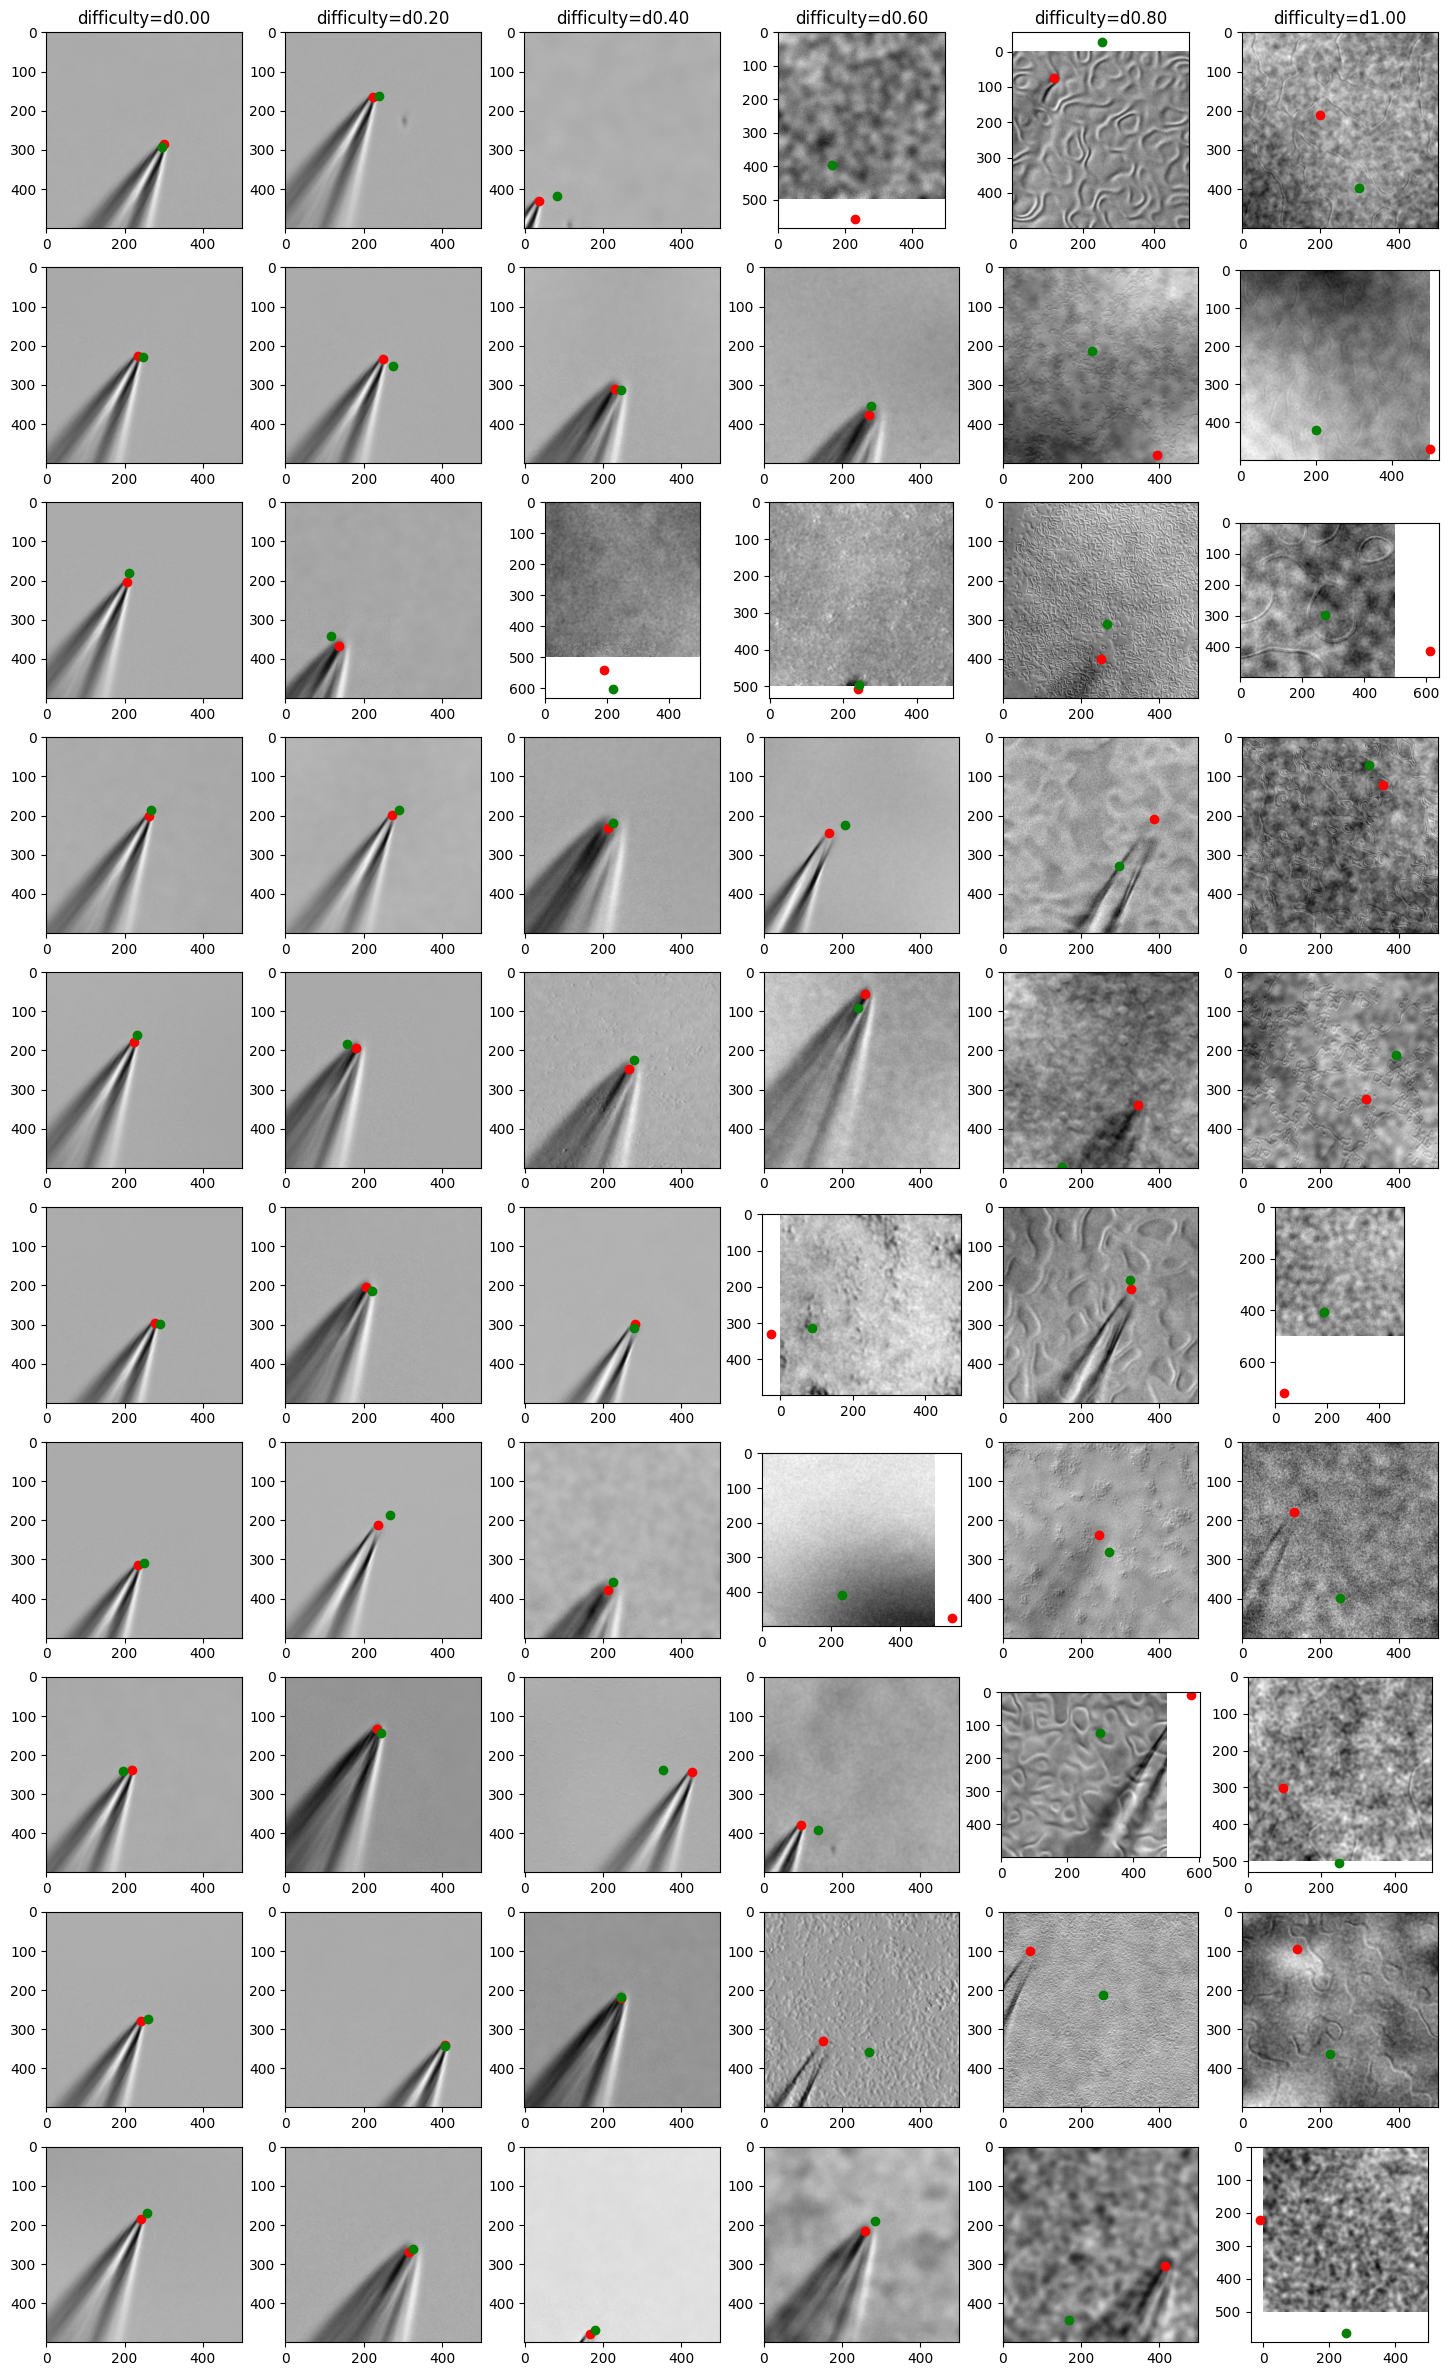

In [10]:
shape = (10, len(levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j, level in enumerate(levels):
    ax[0,j].set_title(f"difficulty={level}")
    image, pip_pos = training_data.levels[level][:shape[0]].get_arrays()
    pip_pos = training_data.output_norm.denormalize(pip_pos)
    pred = training_data.output_norm.denormalize(model.model.predict(image))
    for i in range(shape[0]):
        ax[i,j].imshow(image[i], cmap='gray')
        ax[i,j].scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
        ax[i,j].scatter(pred[i, 2], pred[i, 1], color='green')
        